In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import optuna
from sklearn.feature_selection import VarianceThreshold,RFE, mutual_info_classif
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix,accuracy_score, precision_score, recall_score, f1_score, make_scorer, precision_recall_curve, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [6]:
fold_1_train = pd.read_csv('/Users/Berniss/Downloads/data/preprocessed/fold_1_train.csv')
fold_2_train = pd.read_csv('/Users/Berniss/Downloads/data/preprocessed/fold_2_train.csv')
fold_3_train = pd.read_csv('/Users/Berniss/Downloads/data/preprocessed/fold_3_train.csv')
fold_4_train = pd.read_csv('/Users/Berniss/Downloads/data/preprocessed/fold_4_train.csv')
fold_5_train = pd.read_csv('/Users/Berniss/Downloads/data/preprocessed/fold_5_train.csv')

fold_1_val = pd.read_csv('/Users/Berniss/Downloads/data/preprocessed/fold_1_val.csv')
fold_2_val = pd.read_csv('/Users/Berniss/Downloads/data/preprocessed/fold_2_val.csv')
fold_3_val = pd.read_csv('/Users/Berniss/Downloads/data/preprocessed/fold_3_val.csv')
fold_4_val = pd.read_csv('/Users/Berniss/Downloads/data/preprocessed/fold_4_val.csv')
fold_5_val = pd.read_csv('/Users/Berniss/Downloads/data/preprocessed/fold_5_val.csv')

In [7]:
train_folds = [fold_1_train, fold_2_train, fold_3_train, fold_4_train, fold_5_train]
val_folds = [fold_1_val, fold_2_val, fold_3_val, fold_4_val, fold_5_val]

In [8]:
# Concatenate SMOTEd folds 1-4 for training
training_data = pd.concat([fold_1_train, fold_2_train, fold_3_train, fold_4_train])
X_train = training_data.drop(columns='fraud_bool')
y_train = training_data['fraud_bool']

# Use fold 5 as validation
X_val = fold_5_val.drop(columns='fraud_bool') 
y_val = fold_5_val['fraud_bool']

In [9]:
# Scale using training fold only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [10]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [11]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)

xgb_model.fit(X_train_scaled, y_train)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:59:44] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=-1,
              num_parallel_tree=None, ...)

In [12]:
# Get fraud probabilities
rf_probs = rf_model.predict_proba(X_val_scaled)[:, 1]
xgb_probs = xgb_model.predict_proba(X_val_scaled)[:, 1]

In [13]:
# Blending (adjust weights as needed)
blended_probs = 0.5 * rf_probs + 0.5 * xgb_probs

# Convert to binary prediction with threshold
threshold = 0.5  # Tune this if needed
blended_preds = (blended_probs >= threshold).astype(int)

In [14]:
def evaluate_model(y_true, y_pred, y_proba=None, plot_pr_curve=True):
    print("Classification Report:")
    print(classification_report(y_true, y_pred, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix:")
    print(cm)

    # Key Metrics
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\nPrecision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")

    metrics = {
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'confusion_matrix': cm.tolist()
    }

    # Probabilistic metrics
    if y_proba is not None:
        # AUC-PR (best for imbalanced problems)
        pr_auc = average_precision_score(y_true, y_proba)
        metrics['auc_pr'] = pr_auc
        print(f"AUC-PR (Average Precision): {pr_auc:.4f}")

        # ROC AUC 
        roc_auc = roc_auc_score(y_true, y_proba)
        metrics['roc_auc'] = roc_auc
        print(f"ROC AUC:                   {roc_auc:.4f}")

        # PR Curve
        if plot_pr_curve:
            precision_pts, recall_pts, _ = precision_recall_curve(y_true, y_proba)
            plt.figure(figsize=(6, 5))
            plt.plot(recall_pts, precision_pts, marker='.', label='PR Curve')
            plt.xlabel('Recall')
            plt.ylabel('Precision')
            plt.title(f'Precision-Recall Curve (AUC = {pr_auc:.4f})')
            plt.grid(True)
            plt.legend()
            plt.tight_layout()
            plt.show()

    return metrics

Classification Report:
              precision    recall  f1-score   support

           0     0.9984    1.0000    0.9992    178711
           1     1.0000    0.8479    0.9177      1920

    accuracy                         0.9984    180631
   macro avg     0.9992    0.9240    0.9584    180631
weighted avg     0.9984    0.9984    0.9983    180631


Confusion Matrix:
[[178711      0]
 [   292   1628]]

Precision: 1.0000
Recall:    0.8479
F1 Score:  0.9177
AUC-PR (Average Precision): 1.0000
ROC AUC:                   1.0000


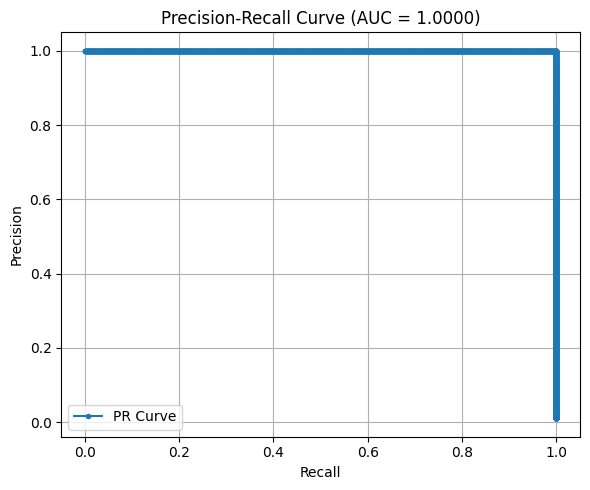

In [15]:
# Evaluate ensemble model
metrics = evaluate_model(y_val, blended_preds, y_proba=blended_probs, plot_pr_curve=True)

### Optuna Hyperparameter Tuning

In [16]:
# Sample 1 million rows while preserving the 50/50 balance
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train_scaled,
    y_train,
    train_size=1_000_000,
    stratify=y_train,
    random_state=42
)

In [22]:
def objective(trial):
    # Random Forest hyperparameters
    rf_n_estimators = trial.suggest_int('rf_n_estimators', 50, 300)
    rf_max_depth = trial.suggest_int('rf_max_depth', 3, 20)
    rf_min_samples_split = trial.suggest_int('rf_min_samples_split', 2, 20)

    # XGBoost hyperparameters
    xgb_n_estimators = trial.suggest_int('xgb_n_estimators', 50, 300)
    xgb_max_depth = trial.suggest_int('xgb_max_depth', 3, 15)
    xgb_learning_rate = trial.suggest_float('xgb_learning_rate', 0.01, 0.3)
    xgb_subsample = trial.suggest_float('xgb_subsample', 0.5, 1.0)
    xgb_colsample_bytree = trial.suggest_float('xgb_colsample_bytree', 0.5, 1.0)

    # Blending weight
    blend_weight = trial.suggest_float('blend_weight', 0.1, 0.9)

    # Initialize models
    rf = RandomForestClassifier(
        n_estimators=rf_n_estimators,
        max_depth=rf_max_depth,
        min_samples_split=rf_min_samples_split,
        random_state=42,
        n_jobs=-1
    )

    xgb = XGBClassifier(
        n_estimators=xgb_n_estimators,
        max_depth=xgb_max_depth,
        learning_rate=xgb_learning_rate,
        subsample=xgb_subsample,
        colsample_bytree=xgb_colsample_bytree,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )

    # Train
    rf.fit(X_train_sample, y_train_sample)
    xgb.fit(X_train_sample, y_train_sample)

    # Predict probabilities
    rf_probs = rf.predict_proba(X_val_scaled)[:, 1]
    xgb_probs = xgb.predict_proba(X_val_scaled)[:, 1]
    blended_probs = (1 - blend_weight) * rf_probs + blend_weight * xgb_probs

    # Return AUC-PR (average precision)
    return average_precision_score(y_val, blended_probs)

# Run Optuna study
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10, show_progress_bar=True)

# Best results
print("\nBest AUC-PR:", study.best_value)
print("Best Hyperparameters:", study.best_params)

[I 2025-04-09 22:23:04,281] A new study created in memory with name: no-name-b8db7523-151d-4388-a930-4752e156bf72


  0%|          | 0/10 [00:00<?, ?it/s]

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [22:25:33] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2025-04-09 22:25:41,330] Trial 0 finished with value: 0.1747752769065986 and parameters: {'rf_n_estimators': 102, 'rf_max_depth': 19, 'rf_min_samples_split': 6, 'xgb_n_estimators': 97, 'xgb_max_depth': 5, 'xgb_learning_rate': 0.2795122876284282, 'xgb_subsample': 0.658590611315234, 'xgb_colsample_bytree': 0.8021475963682916, 'blend_weight': 0.6089704006919668}. Best is trial 0 with value: 0.1747752769065986.


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [22:28:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


...

[I 2025-04-09 22:57:19,283] Trial 7 finished with value: 0.14306210075081838 and parameters: {'rf_n_estimators': 259, 'rf_max_depth': 17, 'rf_min_samples_split': 6, 'xgb_n_estimators': 214, 'xgb_max_depth': 3, 'xgb_learning_rate': 0.22762371046405946, 'xgb_subsample': 0.6817352211520404, 'xgb_colsample_bytree': 0.8661111006703557, 'blend_weight': 0.7082532665239939}. Best is trial 3 with value: 0.5231985434989379.


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [22:58:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2025-04-09 22:58:14,866] Trial 8 finished with value: 0.11028897128076688 and parameters: {'rf_n_estimators': 125, 'rf_max_depth': 3, 'rf_min_samples_split': 20, 'xgb_n_estimators': 112, 'xgb_max_depth': 4, 'xgb_learning_rate': 0.26760781791415106, 'xgb_subsample': 0.7681277490762857, 'xgb_colsample_bytree': 0.7358940812267796, 'blend_weight': 0.41639537485162115}. Best is trial 3 with value: 0.5231985434989379.


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [22:59:54] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2025-04-09 23:00:14,950] Trial 9 finished with value: 0.656024064687008 and parameters: {'rf_n_estimators': 73, 'rf_max_depth': 16, 'rf_min_samples_split': 16, 'xgb_n_estimators': 131, 'xgb_max_depth': 14, 'xgb_learning_rate': 0.1521493212878888, 'xgb_subsample': 0.6350796728415432, 'xgb_colsample_bytree': 0.9854426164662824, 'blend_weight': 0.8814464221077807}. Best is trial 9 with value: 0.656024064687008.

Best AUC-PR: 0.656024064687008
Best Hyperparameters: {'rf_n_estimators': 73, 'rf_max_depth': 16, 'rf_min_samples_split': 16, 'xgb_n_estimators': 131, 'xgb_max_depth': 14, 'xgb_learning_rate': 0.1521493212878888, 'xgb_subsample': 0.6350796728415432, 'xgb_colsample_bytree': 0.9854426164662824, 'blend_weight': 0.8814464221077807}


In [23]:
# Extract best parameters
best_params = study.best_params
blend_weight = best_params['blend_weight']

# Rebuild best models
best_rf = RandomForestClassifier(
    n_estimators=best_params['rf_n_estimators'],
    max_depth=best_params['rf_max_depth'],
    min_samples_split=best_params['rf_min_samples_split'],
    random_state=42,
    n_jobs=-1
)

best_xgb = XGBClassifier(
    n_estimators=best_params['xgb_n_estimators'],
    max_depth=best_params['xgb_max_depth'],
    learning_rate=best_params['xgb_learning_rate'],
    subsample=best_params['xgb_subsample'],
    colsample_bytree=best_params['xgb_colsample_bytree'],
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

In [24]:
best_rf.fit(X_train_scaled, y_train)

RandomForestClassifier(max_depth=16, min_samples_split=16, n_estimators=73,
                       n_jobs=-1, random_state=42)

In [25]:
best_xgb.fit(X_train_scaled, y_train)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:13:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9854426164662824, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1521493212878888,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=14, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=131, n_jobs=-1,
              num_parallel_tree=None, ...)

In [26]:
# Predict probabilities on validation set
rf_probs_best = best_rf.predict_proba(X_val_scaled)[:, 1]
xgb_probs_best = best_xgb.predict_proba(X_val_scaled)[:, 1]
blended_probs_best = (1 - blend_weight) * rf_probs_best + blend_weight * xgb_probs_best

In [27]:
# Tune threshold to maximize F1
thresholds = np.linspace(0.01, 0.99, 100)
f1_scores = []

for t in thresholds:
    preds = (blended_probs_best >= t).astype(int)
    f1 = f1_score(y_val, preds)
    f1_scores.append(f1)

best_thresh = thresholds[np.argmax(f1_scores)]
print(f"\nOptimal Threshold for F1: {best_thresh:.4f}")


Optimal Threshold for F1: 0.3862


Classification Report:
              precision    recall  f1-score   support

           0     0.9998    0.9999    0.9999    178711
           1     0.9911    0.9844    0.9877      1920

    accuracy                         0.9997    180631
   macro avg     0.9955    0.9921    0.9938    180631
weighted avg     0.9997    0.9997    0.9997    180631


Confusion Matrix:
[[178694     17]
 [    30   1890]]

Precision: 0.9911
Recall:    0.9844
F1 Score:  0.9877
AUC-PR (Average Precision): 0.9988
ROC AUC:                   1.0000


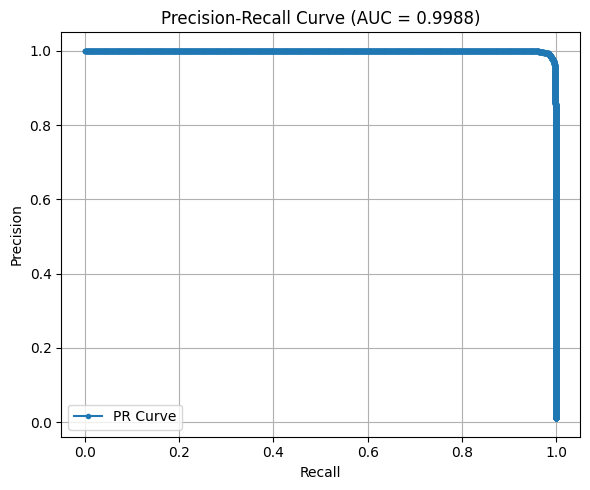

{'precision': 0.9910854745673833,
 'recall': 0.984375,
 'f1_score': 0.9877188398223151,
 'confusion_matrix': [[178694, 17], [30, 1890]],
 'auc_pr': 0.9988414201790468,
 'roc_auc': 0.9999806076570552}

In [28]:
final_preds = (blended_probs_best >= best_thresh).astype(int)
evaluate_model(y_val, final_preds, blended_probs_best)